# Sistema de diagnóstico de ritmo cardíaco basado en ECG
## Proyecto Final – Procesamiento de Señales
 
**Base de datos:** MIT-BIH Arrhythmia Database  
**Objetivo:** Clasificar latidos entre ritmo normal y acelerado / anormal a partir de ECG, y diseñar un pipeline reutilizable para señales físicas.


## Configuración del entorno virtual

Para asegurar la reproducibilidad del proyecto, se creó un entorno virtual en Python utilizando `venv`. Todas las librerías necesarias fueron instaladas dentro de este entorno.

### Creación del entorno virtual:

```bash
python -m venv venv


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wfdb                      # para leer MIT-BIH
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

# Configuración opcional
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True


## 2. Carga de datos (MIT-BIH) y visualización inicial

En esta sección se carga un registro de ejemplo de la base MIT-BIH Arrhythmia Database, se visualiza la señal de ECG y se verifica la frecuencia de muestreo y las anotaciones de latidos.

Frecuencia de muestreo: 360
Canales: ['MLII', 'V5']
Shape de la señal: (650000, 2)
Número de anotaciones: 2274


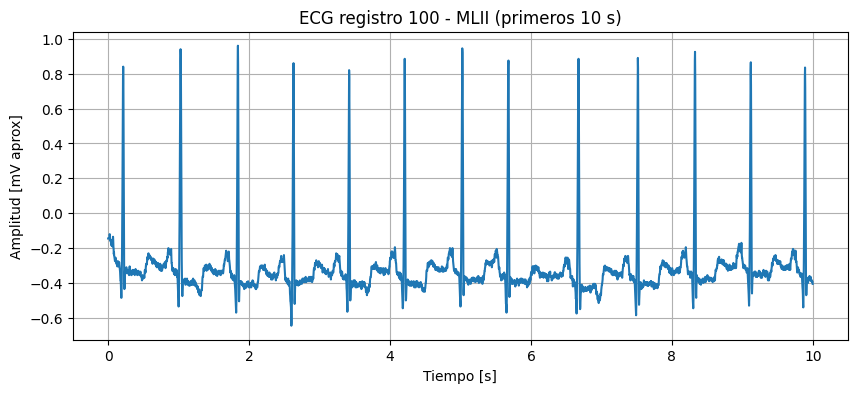

In [2]:
import wfdb

record_name = "100"  # empezamos con un registro de prueba

record = wfdb.rdrecord(record_name, pn_dir="mitdb")
ann = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

signal = record.p_signal
fs = record.fs
chan_names = record.sig_name

print("Frecuencia de muestreo:", fs)
print("Canales:", chan_names)
print("Shape de la señal:", signal.shape)
print("Número de anotaciones:", len(ann.sample))

ecg = signal[:, 0]  # usamos la primera derivación (típicamente MLII)

# Graficar primeros 10 segundos
dur_s = 10
n_samples = int(dur_s * fs)
t = np.arange(n_samples) / fs

plt.plot(t, ecg[:n_samples])
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV aprox]")
plt.title(f"ECG registro {record_name} - {chan_names[0]} (primeros {dur_s} s)")
plt.show()


## 3. Funciones auxiliares para cargar registros y extraer latidos

A partir de las anotaciones de MIT-BIH se extraen ventanas centradas en cada latido (pico R), que luego se usarán para extraer características.


In [3]:
def load_mitdb_record(rec_name: str, lead_index: int = 0):
    """Carga un registro de MIT-BIH y devuelve ecg, fs y anotaciones."""
    record = wfdb.rdrecord(rec_name, pn_dir="mitdb")
    ann = wfdb.rdann(rec_name, "atr", pn_dir="mitdb")
    signal = record.p_signal
    fs = record.fs
    ecg = signal[:, lead_index]
    return ecg, fs, ann

def get_beats_and_rr_from_record(ecg, fs, ann, win_ms_before=200, win_ms_after=400):
    """
    Extrae ventanas alrededor de cada muestra anotada (pico R) y calcula
    el intervalo RR previo para cada latido.

    Retorna
    -------
    beats : np.ndarray
        Ventanas de ECG centradas en cada latido.
    labels : np.ndarray
        Símbolos de anotación (ej. 'N', 'V', etc.).
    rr_prev_list : np.ndarray
        Intervalo RR previo para cada latido (en segundos).
        Para el primer latido de cada registro se coloca -1.0.
    """
    samples = ann.sample
    symbols = ann.symbol

    # RR intervals en segundos entre R-peaks consecutivos
    rr_intervals = np.diff(samples) / fs  # len = num_latidos - 1

    win_before = int(win_ms_before * 1e-3 * fs)
    win_after  = int(win_ms_after * 1e-3 * fs)
    win_len    = win_before + win_after

    beats = []
    labels = []
    rr_prev_list = []

    for idx, s in enumerate(samples):
        start = s - win_before
        end = s + win_after
        if start < 0 or end > len(ecg):
            continue

        seg = ecg[start:end]
        if len(seg) != win_len:
            continue

        beats.append(seg)
        labels.append(symbols[idx])

        # RR previo: para el primer latido no hay, usamos -1.0
        if idx == 0:
            rr_prev_list.append(-1.0)
        else:
            rr_prev_list.append(rr_intervals[idx - 1])

    return np.array(beats), np.array(labels), np.array(rr_prev_list)

# Probar con el registro 100
ecg_100, fs_100, ann_100 = load_mitdb_record("100")
beats_100, labels_100, rr_100 = get_beats_and_rr_from_record(ecg_100, fs_100, ann_100)

print("Latidos extraídos:", beats_100.shape)
print("Ejemplos de etiquetas:", np.unique(labels_100))
print("Ejemplos de RR previos:", rr_100[:10])


Latidos extraídos: (2272, 216)
Ejemplos de etiquetas: ['A' 'N' 'V']
Ejemplos de RR previos: [0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


## 4. Construcción del dataset de latidos y etiquetado

Se seleccionan los latidos normales y anormales para un problema binario:
- Clase 0: latido normal ('N')
- Clase 1: otros tipos de latidos (ritmo anormal / potencialmente acelerado)


In [4]:
MITDB_RECORDS = [
    "100", "101", "103", "105", "106",
    "108", "109", "111", "112", "113",
    "115", "116", "118", "119", "121",
    "122", "123", "124", "200", "201",
    "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214",
    "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231",
    "232", "233", "234"
]

def map_label_to_binary(symbol: str) -> int | None:
    """Mapea un símbolo MIT-BIH a clase binaria.
       Devuelve 0, 1 o None si no se quiere usar ese latido.
    """
    if symbol == 'N':
        return 0
    # Aquí puedes afinar qué tipos considers "acelerados/anormales"
    # por ahora todo lo no N lo marcamos como 1
    return 1

all_beats = []
all_labels = []
all_rr_prev = []

for rec in MITDB_RECORDS:
    try:
        ecg, fs_rec, ann_rec = load_mitdb_record(rec)
        beats, labels, rr_prev_list = get_beats_and_rr_from_record(ecg, fs_rec, ann_rec)
        
        for b, lab, rr_prev in zip(beats, labels, rr_prev_list):
            y = map_label_to_binary(lab)
            if y is not None:
                all_beats.append(b)
                all_labels.append(y)
                all_rr_prev.append(rr_prev)
    except Exception as e:
        print(f"Error con registro {rec}: {e}")

all_beats = np.array(all_beats)
all_labels = np.array(all_labels)
all_rr_prev = np.array(all_rr_prev)

print("Total de latidos en el dataset:", all_beats.shape)
unique, counts = np.unique(all_labels, return_counts=True)
print("Distribución de clases:", dict(zip(unique, counts)))
print("RR previos - ejemplo:", all_rr_prev[:10])

Total de latidos en el dataset: (102509, 216)
Distribución de clases: {np.int64(0): np.int64(71413), np.int64(1): np.int64(31096)}
RR previos - ejemplo: [0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


## 5. Preprocesamiento de latidos (filtrado y normalización)

En esta sección se implementan filtros básicos para el ECG y se normalizan los latidos antes de extraer características.


In [5]:
from scipy.signal import butter, filtfilt

def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, x)

# Aplicar normalización simple beat-wise
def normalize_beat(beat):
    beat = beat - np.mean(beat)
    std = np.std(beat)
    if std == 0:
        return beat
    return beat / std

# Normalizar todos los latidos
all_beats_filt = np.array([normalize_beat(b) for b in all_beats])
print("Shape beats filtrados/normalizados:", all_beats_filt.shape)


Shape beats filtrados/normalizados: (102509, 216)


## 6. Extracción de características por latido

Se definen y calculan características simples de cada latido en el dominio del tiempo y frecuencia, que serán la entrada del modelo de clasificación.


In [6]:
from scipy.fft import rfft, rfftfreq

def extract_features_from_beat(beat, fs, rr_prev=None):
    """
    Extrae un conjunto ampliado de características de un latido de ECG.

    Parámetros
    ----------
    beat : np.ndarray
        Ventana del latido (centrada en el pico R, ya normalizada si aplica).
    fs : float
        Frecuencia de muestreo (Hz), típicamente 360 en MIT-BIH.
    rr_prev : float o None
        Intervalo RR anterior en segundos (tiempo entre este R y el previo).
        Si es None o <= 0, se usará el marcador -1.0.

    Retorna
    -------
    feat : np.ndarray
        Vector de características numéricas.
    """
    feat = []

    # -------------------------------
    # 1. Dominio del tiempo (básico)
    # -------------------------------
    mean_val = np.mean(beat)
    std_val = np.std(beat)
    rms = np.sqrt(np.mean(beat ** 2))
    energy = np.sum(beat ** 2)

    max_val = np.max(beat)
    min_val = np.min(beat)
    peak_to_peak = max_val - min_val

    feat.extend([
        mean_val,
        std_val,
        rms,
        energy,
        max_val,
        min_val,
        peak_to_peak
    ])

    # -----------------------------------
    # 2. Aproximación a duración del QRS
    # -----------------------------------
    # Suponemos beat centrado en R. Usamos umbral relativo para estimar ancho.
    beat_abs = np.abs(beat)
    max_abs = np.max(beat_abs)
    if max_abs > 0:
        threshold = 0.5 * max_abs  # 50% del pico máximo
        center = len(beat) // 2

        # Buscar hacia la izquierda
        left = center
        while left > 0 and beat_abs[left] > threshold:
            left -= 1

        # Buscar hacia la derecha
        right = center
        while right < len(beat_abs) - 1 and beat_abs[right] > threshold:
            right += 1

        qrs_samples = right - left
        qrs_duration = qrs_samples / fs  # en segundos
    else:
        qrs_duration = 0.0

    feat.append(qrs_duration)

    # -------------------------------
    # 3. Features de ritmo (RR/BPM)
    # -------------------------------
    if rr_prev is None or rr_prev <= 0:
        rr_val = -1.0  # marcador de "sin dato"
        bpm = -1.0
    else:
        rr_val = rr_prev
        bpm = 60.0 / rr_prev  # latidos por minuto

    feat.extend([rr_val, bpm])

    # ---------------------------------------------
    # 4. Dominio de frecuencia (FFT + energía bandas)
    # ---------------------------------------------
    N = len(beat)
    yf = np.abs(rfft(beat))
    xf = rfftfreq(N, 1 / fs)

    # Frecuencia dominante
    if np.any(yf > 0):
        idx_max = np.argmax(yf)
        f_dom = xf[idx_max]
    else:
        f_dom = 0.0

    # Energía en banda baja (0.5-15 Hz) y media (15-40 Hz)
    low_band = (xf >= 0.5) & (xf <= 15)
    mid_band = (xf > 15) & (xf <= 40)

    e_low = np.sum(yf[low_band] ** 2)
    e_mid = np.sum(yf[mid_band] ** 2)

    # Centroide espectral
    if np.sum(yf) > 0:
        spectral_centroid = np.sum(xf * yf) / np.sum(yf)
    else:
        spectral_centroid = 0.0

    feat.extend([f_dom, e_low, e_mid, spectral_centroid])

    return np.array(feat)


X = []
for beat_norm, rr_prev in zip(all_beats_filt, all_rr_prev):
    feat_vec = extract_features_from_beat(beat_norm, fs_100, rr_prev=rr_prev)
    X.append(feat_vec)

X = np.array(X)
y = all_labels

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (102509, 14)
Shape de y: (102509,)


## 7. Entrenamiento del modelo de clasificación

Se separan los datos en entrenamiento y prueba, se escalan las características y se entrena un modelo Random Forest como clasificador binario.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

feature_names = [
    "mean",
    "std",
    "rms",
    "energy",
    "max_val",
    "min_val",
    "peak_to_peak",
    "qrs_duration",
    "rr_prev",
    "bpm",
    "f_dom",
    "E_low(0.5-15)",
    "E_mid(15-40)",
    "spectral_centroid"
]

print("Características utilizadas por el modelo (en este orden):")
for i, name in enumerate(feature_names):
    print(f"{i}: {name}")
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Características utilizadas por el modelo (en este orden):
0: mean
1: std
2: rms
3: energy
4: max_val
5: min_val
6: peak_to_peak
7: qrs_duration
8: rr_prev
9: bpm
10: f_dom
11: E_low(0.5-15)
12: E_mid(15-40)
13: spectral_centroid

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     14283
           1       0.96      0.93      0.94      6219

    accuracy                           0.97     20502
   macro avg       0.96      0.95      0.96     20502
weighted avg       0.97      0.97      0.97     20502

Matriz de confusión:
[[14046   237]
 [  464  5755]]


## 8. Interpretabilidad

### 8A. importancia de características

Se analizan las características que más contribuyen a la decisión del modelo, como parte del requisito de "diagnóstico explicable".


Importancia de características (%):
mean: 1.69%
std: 0.23%
rms: 0.22%
energy: 0.59%
max_val: 17.33%
min_val: 11.11%
peak_to_peak: 14.41%
qrs_duration: 0.11%
rr_prev: 8.18%
bpm: 8.19%
f_dom: 6.33%
E_low(0.5-15): 10.94%
E_mid(15-40): 10.68%
spectral_centroid: 9.99%


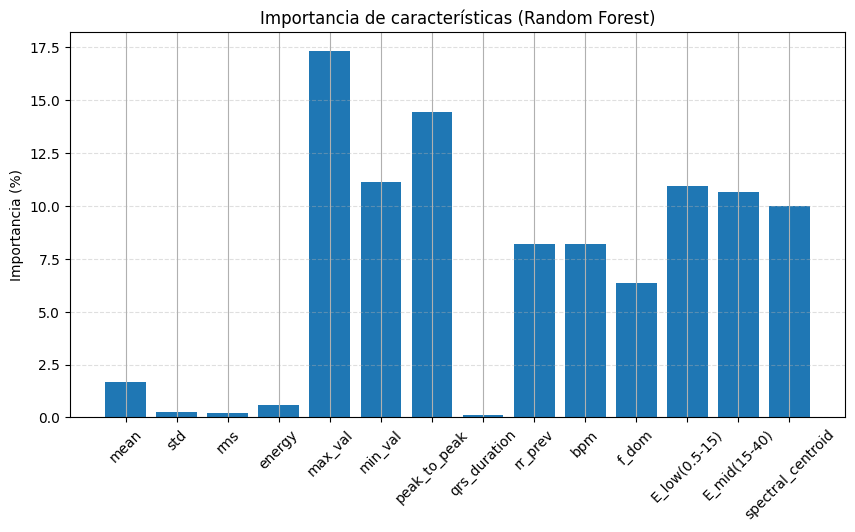

In [8]:
# Importancia de características en porcentaje
importances = clf.feature_importances_
importances_pct = importances * 100  # convertir a porcentaje

print("Importancia de características (%):")
for name, imp in zip(feature_names, importances_pct):
    print(f"{name}: {imp:.2f}%")

# Gráfica
plt.figure(figsize=(10,5))
plt.bar(feature_names, importances_pct)
plt.xticks(rotation=45)
plt.ylabel("Importancia (%)")
plt.title("Importancia de características (Random Forest)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


### 8B. Visualización gráfica de métricas del clasificador

Para analizar el desempeño del modelo de forma más intuitiva, se incluyen:
- Matriz de confusión con mapa de calor
- Curva ROC
- Comparación de precisión por clase



MATRIZ DE CONFUSIÓN:
Esta gráfica compara las etiquetas reales con las predicciones del modelo.
- La diagonal representa las predicciones correctas.
- Los valores fuera de la diagonal representan errores.
- Sirve para ver si el modelo confunde más una clase que la otra.



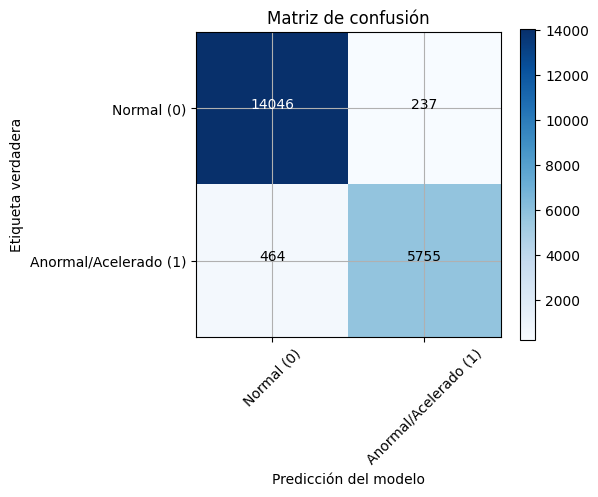


CURVA ROC:
Mide qué tan bien separa el modelo las dos clases.
- En el eje X: tasa de falsos positivos.
- En el eje Y: tasa de verdaderos positivos.
- Mientras más se acerque la curva a la esquina superior izquierda,
  mejor es el modelo.
- El AUC (área bajo la curva) resume el rendimiento global.



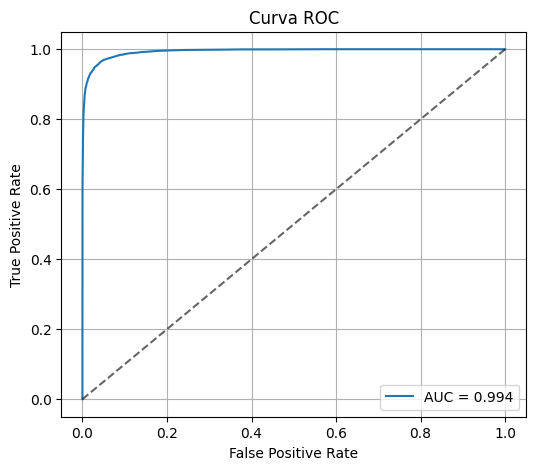


MÉTRICAS POR CLASE:
Aquí se comparan tres métricas importantes entre las dos clases:
- Precision: de todo lo que predije como '1', ¿qué porcentaje era correcto?
- Recall: de todos los verdaderos '1', ¿cuántos pude detectar?
- F1-score: balance entre precision y recall.
Sirve para saber si el modelo es equilibrado o favorece una clase.



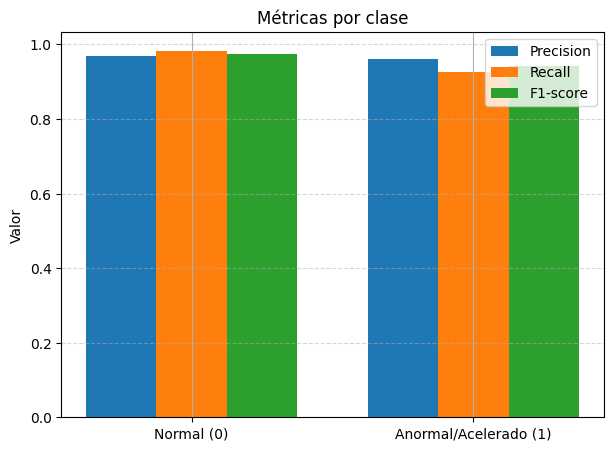

In [9]:
# ---------------------------------------------------------
# 1. Matriz de confusión con mapa de calor
# ---------------------------------------------------------
print("""
MATRIZ DE CONFUSIÓN:
Esta gráfica compara las etiquetas reales con las predicciones del modelo.
- La diagonal representa las predicciones correctas.
- Los valores fuera de la diagonal representan errores.
- Sirve para ver si el modelo confunde más una clase que la otra.
""")

cm = confusion_matrix(y_test, y_pred)
classes = ["Normal (0)", "Anormal/Acelerado (1)"]

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matriz de confusión")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Etiquetas dentro de cada cuadro
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("Etiqueta verdadera")
plt.xlabel("Predicción del modelo")
plt.tight_layout()
plt.show()



# ---------------------------------------------------------
# 2. Curva ROC
# ---------------------------------------------------------
print("""
CURVA ROC:
Mide qué tan bien separa el modelo las dos clases.
- En el eje X: tasa de falsos positivos.
- En el eje Y: tasa de verdaderos positivos.
- Mientras más se acerque la curva a la esquina superior izquierda,
  mejor es el modelo.
- El AUC (área bajo la curva) resume el rendimiento global.
""")

# Probabilidades
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



# ---------------------------------------------------------
# 3. Métricas por clase (gráfica de barras)
# ---------------------------------------------------------
print("""
MÉTRICAS POR CLASE:
Aquí se comparan tres métricas importantes entre las dos clases:
- Precision: de todo lo que predije como '1', ¿qué porcentaje era correcto?
- Recall: de todos los verdaderos '1', ¿cuántos pude detectar?
- F1-score: balance entre precision y recall.
Sirve para saber si el modelo es equilibrado o favorece una clase.
""")

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0,1])

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(7,5))
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, classes)
plt.ylabel("Valor")
plt.title("Métricas por clase")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


### 8C. Visualización de ejemplos de latidos con RR y BPM estimado

En esta sección se muestran algunos latidos individuales del dataset junto con:
- El intervalo RR previo asociado (en milisegundos).
- La frecuencia cardíaca estimada (BPM = 60 / RR).
- La clase asignada (0 = normal, 1 = anormal).

Esto permite visualizar cómo varía la morfología del latido y su ritmo asociado.


Índices de latidos mostrados: [43981 33115 69563 26035 84130 35972]


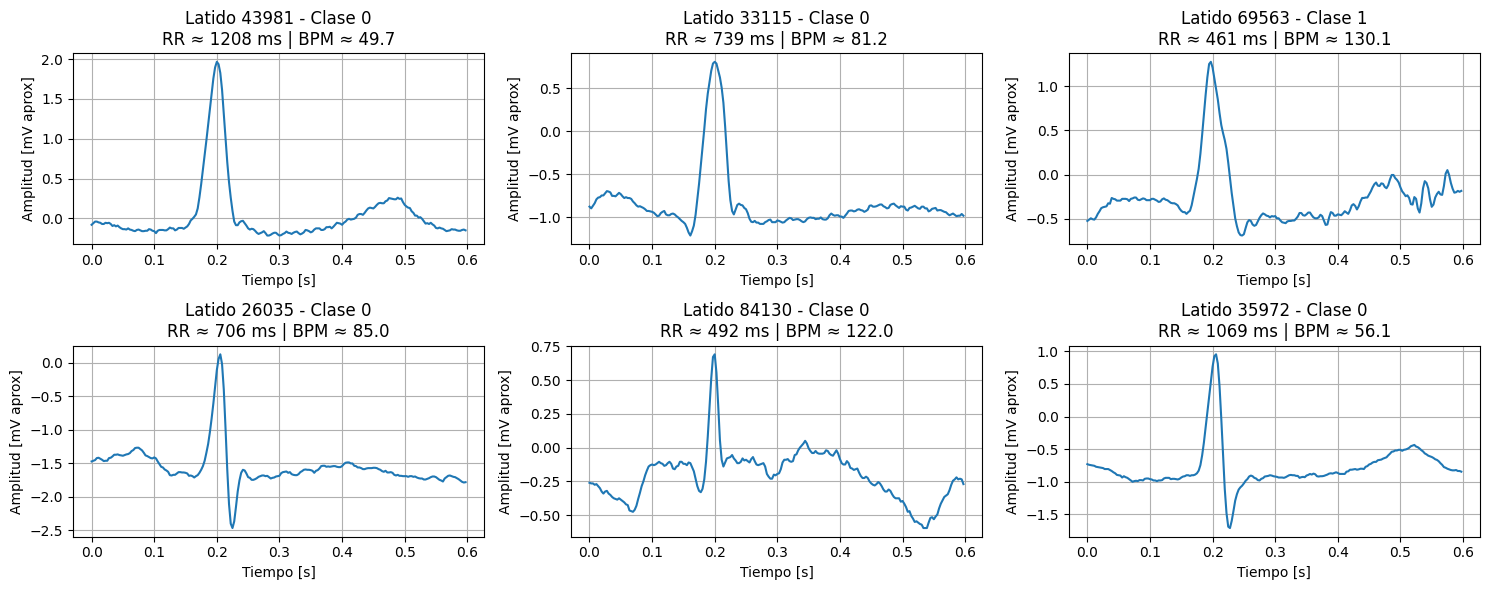

In [10]:
# Seleccionar algunos índices de ejemplo
# Puedes cambiar estos valores o usar np.random.choice
num_examples = 6

# Nos aseguramos de no elegir RR = -1 (sin dato)
valid_indices = np.where(all_rr_prev > 0)[0]

if len(valid_indices) < num_examples:
    print("No hay suficientes latidos con RR válido, se mostrarán menos ejemplos.")
    example_indices = valid_indices
else:
    example_indices = np.random.choice(valid_indices, size=num_examples, replace=False)

print("Índices de latidos mostrados:", example_indices)

# Crear subplots
rows = 2
cols = 3
plt.figure(figsize=(15, 6))

for i, idx in enumerate(example_indices):
    beat = all_beats[idx]           # latido original (sin normalizar)
    rr = all_rr_prev[idx]           # en segundos
    label = all_labels[idx]         # 0 = normal, 1 = anormal

    # Calcular BPM
    if rr > 0:
        bpm = 60.0 / rr
        rr_ms = rr * 1000.0
    else:
        bpm = np.nan
        rr_ms = np.nan

    # Eje de tiempo del beat
    N = len(beat)
    t_beat = np.arange(N) / fs_100  # fs_100 ~ 360 Hz en MIT-BIH

    plt.subplot(rows, cols, i + 1)
    plt.plot(t_beat, beat)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [mV aprox]")

    title = f"Latido {idx} - Clase {label}\nRR ≈ {rr_ms:.0f} ms | BPM ≈ {bpm:.1f}"
    plt.title(title)
    plt.grid(True)

plt.tight_layout()
plt.show()


## 9. Guardar el pipeline entrenado

Se guarda el modelo y el scaler para reutilizarlos con señales físicas futuras.


In [11]:
import joblib

joblib.dump(clf, "ecg_rf_model.pkl")
joblib.dump(scaler, "ecg_scaler.pkl")
np.save("ecg_feature_names.npy", np.array(feature_names))


## 10. Función de clasificación para señales externas (con re-muestreo automático)

La siguiente función implementa el pipeline completo para clasificar un latido externo
(adquirido, por ejemplo, con Arduino).  
Si la señal llega con una frecuencia distinta a 360 Hz (frecuencia oficial del dataset MIT-BIH),
la función la re-muestrea automáticamente para que sea compatible con el modelo entrenado.


### 10A. Clasificación de un latido aislado (beat externo)

En esta sección se define una función (`classify_new_beat`) que permite clasificar **un solo latido de ECG** obtenido externamente (por ejemplo, desde Arduino o desde otro software).  
La función:
- Ajusta la frecuencia de muestreo al valor usado en el entrenamiento (360 Hz) mediante remuestreo si es necesario.
- Normaliza el latido.
- Extrae las mismas características que se usaron para entrenar el modelo.
- Aplica el modelo Random Forest entrenado para decidir si el latido es **normal (0)** o **anormal/acelerado (1)**.


In [12]:
from scipy.signal import resample

# Cargar modelo y scaler previamente guardados
clf_loaded = joblib.load("ecg_rf_model.pkl")
scaler_loaded = joblib.load("ecg_scaler.pkl")

TARGET_FS = 360   # Frecuencia utilizada en MIT-BIH (la del modelo)

def resample_signal(sig, fs_in, fs_target=TARGET_FS):
    """
    Re-muestrea una señal desde fs_in a fs_target usando scipy.resample.
    """
    if fs_in == fs_target:
        return sig  # no tiene que hacer nada

    duration = len(sig) / fs_in
    new_length = int(duration * fs_target)
    
    sig_resampled = resample(sig, new_length)
    return sig_resampled


def classify_new_beat(raw_beat, fs, rr_prev=None):
    """
    Recibe un latido crudo (señal física) y un fs arbitrario.
    - Si fs != 360, remuestrea automáticamente.
    - Normaliza el latido.
    - Extrae características (con rr_prev si se proporciona).
    - Clasifica usando el modelo entrenado.
    """
    # Paso 1: Re-muestreo si el fs no coincide con el del modelo
    if fs != TARGET_FS:
        print(f"[INFO] Re-muestreando beat de {fs} Hz a {TARGET_FS} Hz...")
        beat = resample_signal(raw_beat, fs, TARGET_FS)
    else:
        beat = raw_beat

    # Paso 2: Normalizar
    beat_norm = normalize_beat(beat)

    # Paso 3: Extraer características (rr_prev puede ser None)
    feat_vec = extract_features_from_beat(beat_norm, TARGET_FS, rr_prev=rr_prev)

    # Paso 4: Escalar y predecir
    feat_vec_scaled = scaler_loaded.transform([feat_vec])
    pred = clf_loaded.predict(feat_vec_scaled)[0]

    return pred  # 0 = normal, 1 = anormal/acelerado


# ------------------------------------------------------------
# Ejemplo práctico: usar un beat existente del dataset
# ------------------------------------------------------------
test_beat = all_beats[0]
pred_class = classify_new_beat(test_beat, fs_100)  # fs_100 = 360 Hz en MIT-BIH
print("Predicción para beat de prueba:", pred_class)


Predicción para beat de prueba: 0


### 10B. Clasificación a partir de una señal completa de ECG

En esta sección se extiende el pipeline para trabajar con una **señal continua de ECG**, no solo con beats aislados.  
El flujo es el siguiente:
1. Se remuestrea la señal a 360 Hz si llega con otra frecuencia.
2. Se aplica un filtrado pasa banda para limpiar el ECG.
3. Se detectan los picos R de la señal y se calculan los intervalos RR previos.
4. Se construyen ventanas (beats) centradas en cada R.
5. Para cada beat se extraen características, se escalan y se clasifican con el modelo entrenado.

El resultado es una predicción **beat a beat** para toda la señal de entrada.


In [13]:
from scipy.signal import find_peaks

def detect_r_peaks(ecg, fs, distance_sec=0.25, height_factor=0.5):
    """
    Detector simple de picos R usando scipy.signal.find_peaks sobre la señal normalizada.
    - distance_sec: distancia mínima entre picos (en segundos). 0.25s ~ 240 bpm máx.
    - height_factor: factor sobre la desviación estándar para el umbral de altura.
    """
    ecg_norm = ecg - np.mean(ecg)
    ecg_norm = ecg_norm / (np.std(ecg_norm) + 1e-8)

    distance = int(distance_sec * fs)
    height = height_factor * np.std(ecg_norm)

    peaks, _ = find_peaks(ecg_norm, distance=distance, height=height)
    return peaks


def build_beats_and_rr_from_signal(ecg, fs, win_ms_before=200, win_ms_after=400):
    """
    A partir de una señal continua de ECG:
    - Detecta picos R.
    - Construye ventanas (beats) centradas en cada R.
    - Calcula el RR previo correspondiente.

    Retorna:
    beats : np.ndarray (num_beats, win_len)
    rr_prev_list : np.ndarray (num_beats,)
    """
    r_peaks = detect_r_peaks(ecg, fs)
    if len(r_peaks) < 2:
        print("Advertencia: muy pocos picos R detectados en la señal.")
    
    rr_intervals = np.diff(r_peaks) / fs  # en segundos

    win_before = int(win_ms_before * 1e-3 * fs)
    win_after  = int(win_ms_after * 1e-3 * fs)
    win_len    = win_before + win_after

    beats = []
    rr_prev_list = []

    for idx, s in enumerate(r_peaks):
        start = s - win_before
        end = s + win_after
        if start < 0 or end > len(ecg):
            continue

        seg = ecg[start:end]
        if len(seg) != win_len:
            continue

        beats.append(seg)

        if idx == 0:
            rr_prev_list.append(-1.0)
        else:
            rr_prev_list.append(rr_intervals[idx - 1])

    return np.array(beats), np.array(rr_prev_list)


def classify_from_ecg_segment(raw_ecg, fs):
    """
    Recibe una señal de ECG continua (por ejemplo, tomada con Arduino durante varios segundos)
    y una frecuencia de muestreo cualquiera.
    
    - Remuestrea a 360 Hz si es necesario.
    - Filtra y normaliza la señal.
    - Detecta picos R y calcula RR previos.
    - Construye beats alrededor de cada R.
    - Extrae características y clasifica cada beat.

    Retorna:
    preds : np.ndarray con las predicciones por latido (0 = normal, 1 = anormal).
    beats : np.ndarray con los beats usados.
    rr_prev_list : np.ndarray con los RR previos (s).
    """
    # 1) Remuestreo si hace falta
    if fs != TARGET_FS:
        print(f"[INFO] Re-muestreando señal completa de {fs} Hz a {TARGET_FS} Hz...")
        ecg_rs = resample_signal(raw_ecg, fs, TARGET_FS)
        fs_eff = TARGET_FS
    else:
        ecg_rs = raw_ecg
        fs_eff = fs

    # 2) Filtrado en banda (reutilizamos tu bandpass_filter)
    ecg_filt = bandpass_filter(ecg_rs, fs_eff)

    # 3) Extraer beats y RR previo desde la señal continua
    beats, rr_prev_list = build_beats_and_rr_from_signal(ecg_filt, fs_eff)

    if len(beats) == 0:
        print("No se pudieron construir beats a partir de la señal.")
        return np.array([]), np.array([]), np.array([])

    # 4) Normalizar beats, extraer features y clasificar
    feats = []
    for beat, rr_prev in zip(beats, rr_prev_list):
        beat_norm = normalize_beat(beat)
        feat_vec = extract_features_from_beat(beat_norm, fs_eff, rr_prev=rr_prev)
        feats.append(feat_vec)

    feats = np.array(feats)
    feats_scaled = scaler_loaded.transform(feats)
    preds = clf_loaded.predict(feats_scaled)

    return preds, beats, rr_prev_list


### 10C. Prueba de clasificación usando un registro de MIT-BIH

En esta sección se utiliza un registro completo de la base de datos MIT-BIH como si fuera una señal externa (por ejemplo, adquirida con Arduino).  
Se realiza el siguiente procedimiento:

- Se carga el registro seleccionado (por ejemplo, el 105).
- Se extrae la derivación principal de ECG y su frecuencia de muestreo.
- Se ejecuta la función `classify_from_ecg_segment` para detectar picos R, calcular RR, extraer beats y clasificarlos.
- Se muestran:
  - El número de latidos detectados.
  - Algunas de las primeras predicciones del modelo.
  - Ejemplos de beats graficados con su BPM estimado y su clase predicha.

Esto sirve como validación de extremo a extremo del pipeline sobre una señal real de la base de datos.


Cargando registro 105...
Señal completa cargada:
Duración en muestras: 650000
Frecuencia de muestreo: 360

Clasificando beats del registro completo...

Beats detectados: 2847
Primeras predicciones (0=normal, 1=anormal): [1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 0 0 0 0]
Primeros RR estimados (s): [0.46944444 0.72777778 0.69444444 0.71111111 0.71388889 0.71388889
 0.72777778 0.76388889 0.75277778 0.73333333]
Primeros BPM estimados: [np.float64(127.81065088757397), np.float64(82.44274809160305), np.float64(86.4), np.float64(84.375), np.float64(84.04669260700389), np.float64(84.04669260700389), np.float64(82.44274809160305), np.float64(78.54545454545455), np.float64(79.70479704797049), np.float64(81.81818181818183)]


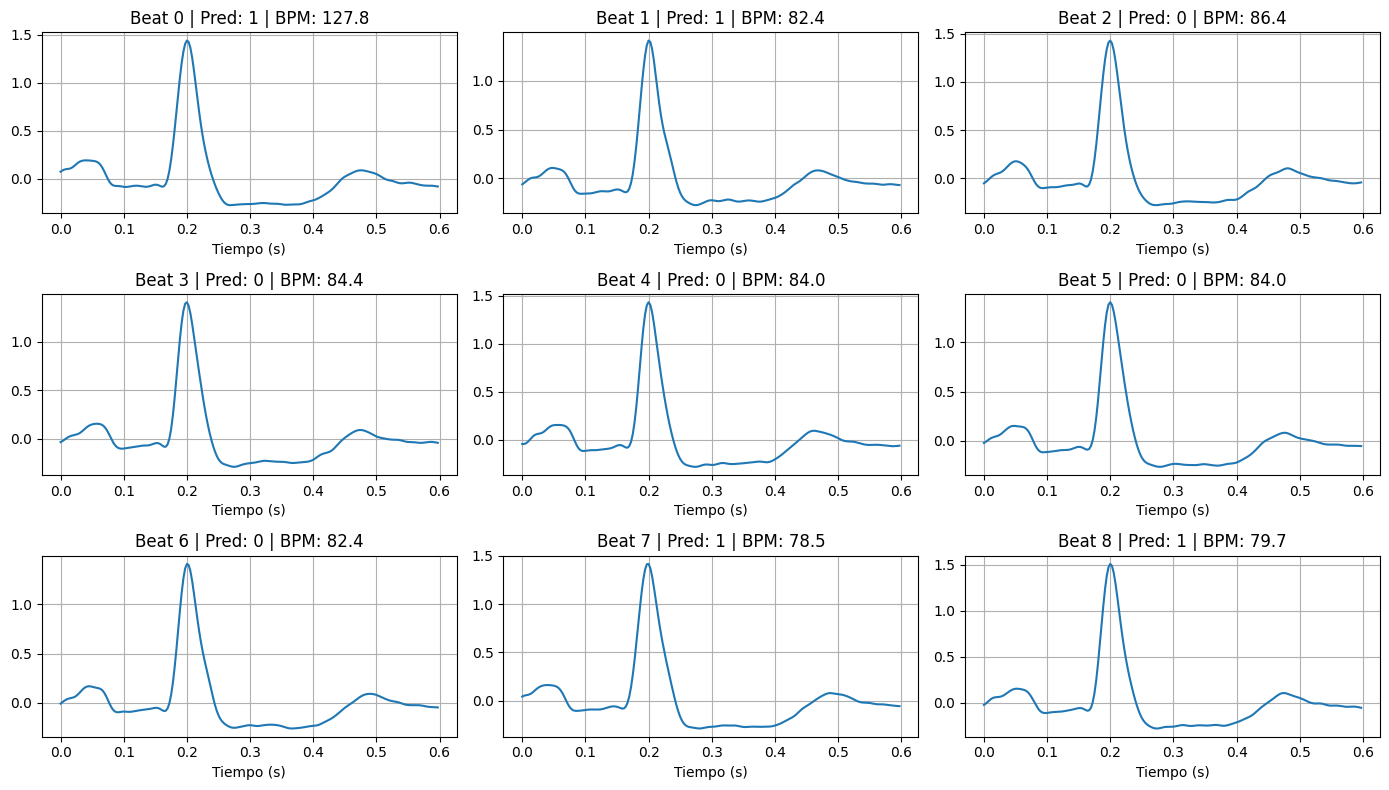

In [14]:
# ============================================
# PRUEBA: Clasificación desde un registro MIT-BIH
# ============================================

# 1. Cargar un registro completo
rec_name = "105"   
print(f"Cargando registro {rec_name}...")

record = wfdb.rdrecord(rec_name, pn_dir="mitdb")
ecg_full = record.p_signal[:, 0]     # Canal MLII
fs_rec = record.fs                   # Frecuencia = 360 Hz

print("Señal completa cargada:")
print("Duración en muestras:", len(ecg_full))
print("Frecuencia de muestreo:", fs_rec)

# 2. Usar la función completa
print("\nClasificando beats del registro completo...\n")

preds, beats_seg, rr_seg = classify_from_ecg_segment(ecg_full, fs_rec)

# 3. Resultados
print("Beats detectados:", len(preds))
print("Primeras predicciones (0=normal, 1=anormal):", preds[:20])
print("Primeros RR estimados (s):", rr_seg[:10])
print("Primeros BPM estimados:", [60/r if r>0 else None for r in rr_seg[:10]])

# 4. Visualizar los primeros 6 beats detectados
plt.figure(figsize=(14, 8))
rows, cols = 3, 3

for i in range(min(9, len(beats_seg))):
    beat = beats_seg[i]
    rr = rr_seg[i]
    bpm = 60/rr if rr > 0 else float('nan')
    
    N = len(beat)
    t_beat = np.arange(N) / fs_rec
    
    plt.subplot(rows, cols, i+1)
    plt.plot(t_beat, beat)
    plt.title(f"Beat {i} | Pred: {preds[i]} | BPM: {bpm:.1f}")
    plt.xlabel("Tiempo (s)")
    plt.grid(True)

plt.tight_layout()
plt.show()


## 11. Prueba directa con señal proveniente de Arduino

En esta sección se deja listo el pipeline para clasificar una señal de ECG
adquirida con Arduino (u otro dispositivo). Solo es necesario:
- Cargar la señal en un vector de NumPy (`ecg_arduino`).
- Especificar la frecuencia de muestreo real (`fs_arduino`).

La función `classify_from_ecg_segment` se encarga del resto:
remuestreo, filtrado, detección de picos R, cálculo de RR,
extracción de características y clasificación por latido.

EJEMPLO: señal externa (Arduino)

- Opción A: Cargar desde un archivo de texto o CSV
Cada línea/columna debe representar una muestra de la señal.
Descomenta y ajusta la ruta si ya tienes el archivo exportado:
ecg_arduino = np.loadtxt("ecg_arduino.txt")  # <-- reemplaza con tu archivo real
fs_arduino = 250.0  # Hz, reemplaza con la frecuencia real de tu módulo
- Opción B: Si ya tienes la señal en memoria (por ejemplo, enviada desde otro script):
ecg_arduino = np.array([...], dtype=float)
fs_arduino = 250.0  # Hz
IMPORTANTE:
Asegúrate de que ecg_arduino y fs_arduino estén definidos antes de ejecutar lo siguiente.

In [15]:
ecg_arduino = np.loadtxt("ecg_arduino_signal.csv")
fs_arduino = 360 # Frecuencia de muestreo del Arduino

Longitud de la señal externa: 10800
Frecuencia de muestreo externa (fs_arduino): 360

Número de latidos detectados: 43
Primeras predicciones (0=normal, 1=anormal): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Primeros BPM estimados: [         nan  90.          96.          98.63013699  96.86098655
 100.         100.93457944 100.          97.2972973   90.        ]


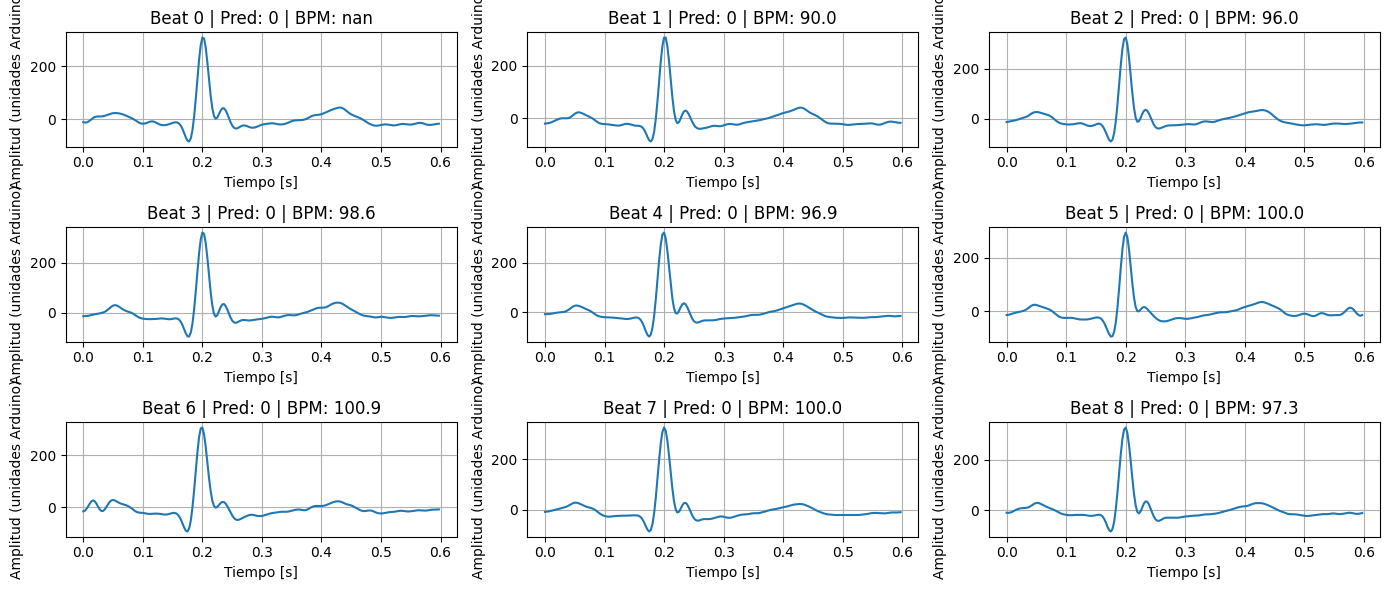

In [16]:
# Comprobación básica
try:
    len(ecg_arduino)
except NameError:
    raise RuntimeError(
        "Debes definir primero 'ecg_arduino' y 'fs_arduino' antes de ejecutar esta celda.\n"
        "Ejemplo:\n"
        "  ecg_arduino = np.loadtxt('ecg_arduino.txt')\n"
        "  fs_arduino = 360"
    )

print("Longitud de la señal externa:", len(ecg_arduino))
print("Frecuencia de muestreo externa (fs_arduino):", fs_arduino)

# Clasificación completa de la señal de Arduino
preds_arduino, beats_arduino, rr_arduino = classify_from_ecg_segment(ecg_arduino, fs_arduino)

print("\nNúmero de latidos detectados:", len(preds_arduino))
print("Primeras predicciones (0=normal, 1=anormal):", preds_arduino[:20])

# Calcular BPM aproximado por beat (donde haya RR válido)
bpm_arduino = np.array([60.0 / r if r > 0 else np.nan for r in rr_arduino])
print("Primeros BPM estimados:", bpm_arduino[:10])

# Graficar algunos beats detectados en la señal externa
num_examples = min(9, len(beats_arduino))
if num_examples == 0:
    print("No se encontraron beats en la señal externa.")
else:
    plt.figure(figsize=(14, 6))
    rows, cols = 3, 3

    for i in range(num_examples):
        beat = beats_arduino[i]
        rr = rr_arduino[i]
        bpm = bpm_arduino[i]

        N = len(beat)
        t_beat = np.arange(N) / TARGET_FS  # ya está remuestreado a 360 Hz

        plt.subplot(rows, cols, i + 1)
        plt.plot(t_beat, beat)
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud (unidades Arduino)")
        plt.title(f"Beat {i} | Pred: {preds_arduino[i]} | BPM: {bpm:.1f}")
        plt.grid(True)

    plt.tight_layout()
    plt.show()